In [3]:
import numpy as np
import scipy.signal as sig
import scipy.linalg as la
import matplotlib.pyplot as plt

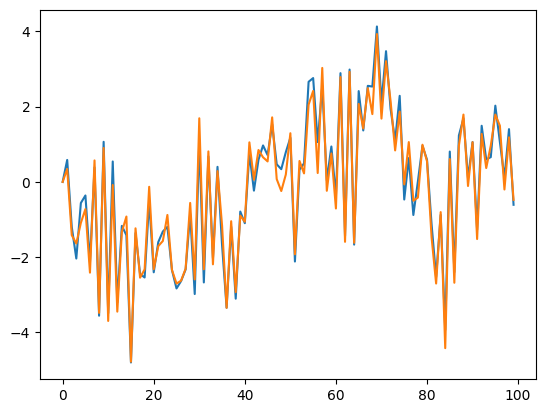

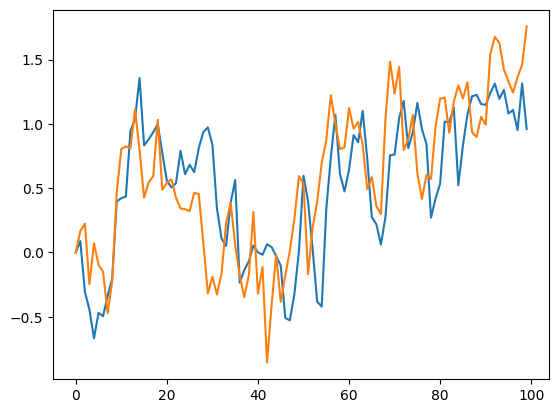

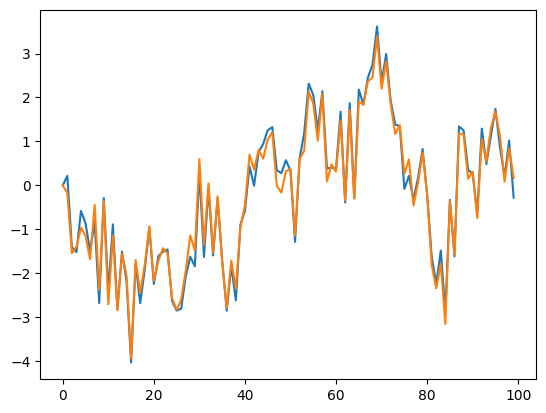

In [24]:
from tkinter import W


Aeig = np.array([0.9, 0.92, -0.8])
C = np.array([[1,1,1],
                [2,1,-1]])


T = np.array([[1,1,2],
              [0,1,0],
              [1,1,1]])
A = T @ np.diag(Aeig) @ la.inv(T)

# process noise covariance
Q = 0.1*np.eye(3)
# measurement noise covariance
R = 0.1*np.array([[1,1],
                [1,2]])

# Generate data
ny = 2
nx = 3
N = 100
x = np.zeros((nx, N))
w = np.zeros((nx, N))
y = np.zeros((ny, N))
v = np.zeros((ny, N))

for k in range(N-1):
    v[:,k] = la.sqrtm(R) @ np.random.randn(ny) # fill in the measurement noise
    w[:,k] = la.sqrtm(Q) @ np.random.randn(nx) # fill in the process noise
    y[:,k] = C @ x[:,k] + v[:,k] # fill in the measurement
    x[:,k+1] = A @ x[:,k] + w[:,k] # fill in the state update

# set up variables for Kalman filter
xhat  = np.zeros((nx, N))
xPred = np.zeros((nx, N))
K = np.zeros((nx, ny, N))
P = np.zeros((nx, nx, N))
Pred = np.zeros((nx, nx, N))


xhat[:,0] = np.zeros(nx) # initial state estimate
T = np.random.rand(nx, nx)
P[:,:,0] = T @ T.T # initial error covariance estimate 


for k in range(1, N):
    # Prediction
    # Prediction step, first compute the predected state at k
    xPred[:,k] = A @ xhat[:,k-1]
    # Then update covariance matrix
    Pred[:,:,k] = A @ P[:,:,k-1] @ A.T + Q

    # Measurement update
    # first compute the Kalman gain
    K[:,:,k] = Pred[:,:,k] @ C.T @ la.inv(C @ Pred[:,:,k] @ C.T + R)
    # Then do the update
    xhat[:,k] = xPred[:,k] + K[:,:,k] @ (y[:,k] - C @ xPred[:,k])
    P[:,:,k] = (np.eye(3)- K[:,:,k]@C)@Pred[:,:,k]

time = np.arange(N)
plt.plot(time, xhat[0,:].T)
plt.plot(time, x[0,:].T)

plt.figure()
plt.plot(time, xhat[1,:].T)
plt.plot(time, x[1,:].T)
plt.figure()  
plt.plot(time, xhat[2,:].T)
plt.plot(time, x[2,:].T)


In [35]:
print(K[:,:,-1])

[[ 0.29371561  0.17745008]
 [ 0.09543327  0.1186243 ]
 [ 0.57980653 -0.32817392]]
